## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import os

path = r'C:\Python by Angela Yu\Day73 - Matplotlib'

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [31]:

df = pd.read_csv(os.path.join(path, "QueryResults.csv"), names=['DATE', 'TAG', 'POST'])
df.head()

,DATE,TAG,POST
0,m,TagName,NaN
1,2008-07-01 00:00:00,c#,3.0
2,2008-08-01 00:00:00,assembly,8.0
3,2008-08-01 00:00:00,javascript,162.0
4,2008-08-01 00:00:00,c,85.0


**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [32]:
# df.head()
df.tail()

,DATE,TAG,POST
1987,2020-07-01 00:00:00,r,5694.0
1988,2020-07-01 00:00:00,go,743.0
1989,2020-07-01 00:00:00,ruby,775.0
1990,2020-07-01 00:00:00,perl,182.0
1991,2020-07-01 00:00:00,swift,3607.0


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [33]:
df.shape

(1992, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [34]:
df.count()

DATE    1992
TAG     1992
POST    1991
dtype: int64

**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [35]:
df_group = df.groupby('TAG')['POST'].sum()
indexMax = df_group.idxmax()
quantMax = df_group.max()
print(indexMax, quantMax)


javascript 2056510.0


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [36]:
df_group = df.groupby('TAG').count()
print(df_group)

            DATE  POST
TAG                   
TagName        1     0
assembly     144   144
c            144   144
c#           145   145
c++          144   144
delphi       144   144
go           129   129
java         144   144
javascript   144   144
perl         144   144
php          144   144
python       144   144
r            142   142
ruby         144   144
swift        135   135


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [38]:
df = df.drop(0)
print(df)

                     DATE         TAG    POST
2     2008-08-01 00:00:00    assembly     8.0
3     2008-08-01 00:00:00  javascript   162.0
4     2008-08-01 00:00:00           c    85.0
5     2008-08-01 00:00:00      python   124.0
6     2008-08-01 00:00:00        perl    28.0
...                   ...         ...     ...
1987  2020-07-01 00:00:00           r  5694.0
1988  2020-07-01 00:00:00          go   743.0
1989  2020-07-01 00:00:00        ruby   775.0
1990  2020-07-01 00:00:00        perl   182.0
1991  2020-07-01 00:00:00       swift  3607.0

[1990 rows x 3 columns]


In [39]:
df.DATE = pd.to_datetime(df.DATE)
df.head()

,DATE,TAG,POST
2,2008-08-01,assembly,8.0
3,2008-08-01,javascript,162.0
4,2008-08-01,c,85.0
5,2008-08-01,python,124.0
6,2008-08-01,perl,28.0


## Data Manipulation



In [40]:
df_pivot = df.pivot_table(index='DATE', columns='TAG', values='POST')
print(df_pivot)

TAG         assembly       c       c#     c++  delphi     go     java  \
DATE                                                                    
2008-08-01       8.0    85.0    511.0   164.0    14.0    NaN    222.0   
2008-09-01      28.0   321.0   1649.0   755.0   105.0    NaN   1137.0   
2008-10-01      15.0   303.0   1989.0   811.0   112.0    NaN   1153.0   
2008-11-01      17.0   259.0   1730.0   735.0   141.0    NaN    958.0   
2008-12-01      18.0   186.0   1597.0   633.0   134.0    NaN    832.0   
...              ...     ...      ...     ...     ...    ...      ...   
2020-03-01     317.0  2670.0   8954.0  5107.0   181.0  719.0  13253.0   
2020-04-01     406.0  3472.0  10042.0  6820.0   250.0  887.0  15377.0   
2020-05-01     386.0  3602.0   9923.0  7063.0   221.0  826.0  14711.0   
2020-06-01     363.0  2757.0   9064.0  6161.0   214.0  765.0  13015.0   
2020-07-01     298.0  2294.0   9145.0  5756.0   212.0  743.0  12723.0   

TAG         javascript   perl     php   python    

**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [41]:
df_pivot.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN
2008-12-01,18.0,186.0,1597.0,633.0,134.0,NaN,832.0,627.0,134.0,481.0,441.0,1.0,161.0,NaN


In [42]:
df.shape

(1990, 3)

In [43]:
df.isna().sum()

DATE    0
TAG     0
POST    0
dtype: int64

**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [50]:
print(df_pivot.sum())

TAG
assembly        34852.0
c              336042.0
c#            1423527.0
c++            684210.0
delphi          46212.0
go              47499.0
java          1696403.0
javascript    2056510.0
perl            65286.0
php           1361988.0
python        1496210.0
r              356799.0
ruby           214582.0
swift          273055.0
dtype: float64


## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

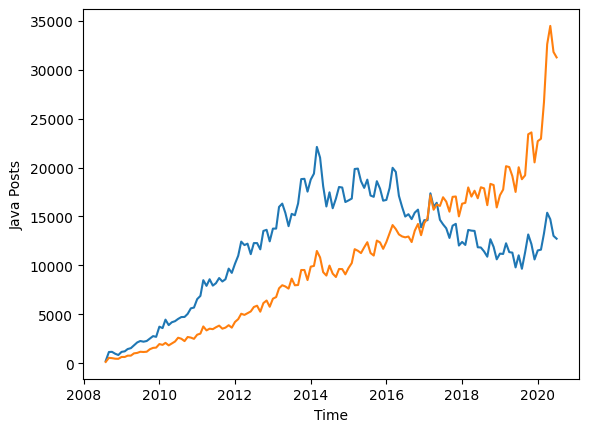

In [52]:
# .figure() - allows us to resize our chart
# .xticks() - configures our x-axis
# .yticks() - configures our y-axis
# .xlabel() - add text to the x-axis
# .ylabel() - add text to the y-axis
# .ylim() - allows us to set a lower and upper bound

plt.xlabel('Time')
plt.ylabel('Java Posts')
plt.plot(df_pivot.index, df_pivot.java)
plt.plot(df_pivot.index, df_pivot.python)
plt.show()

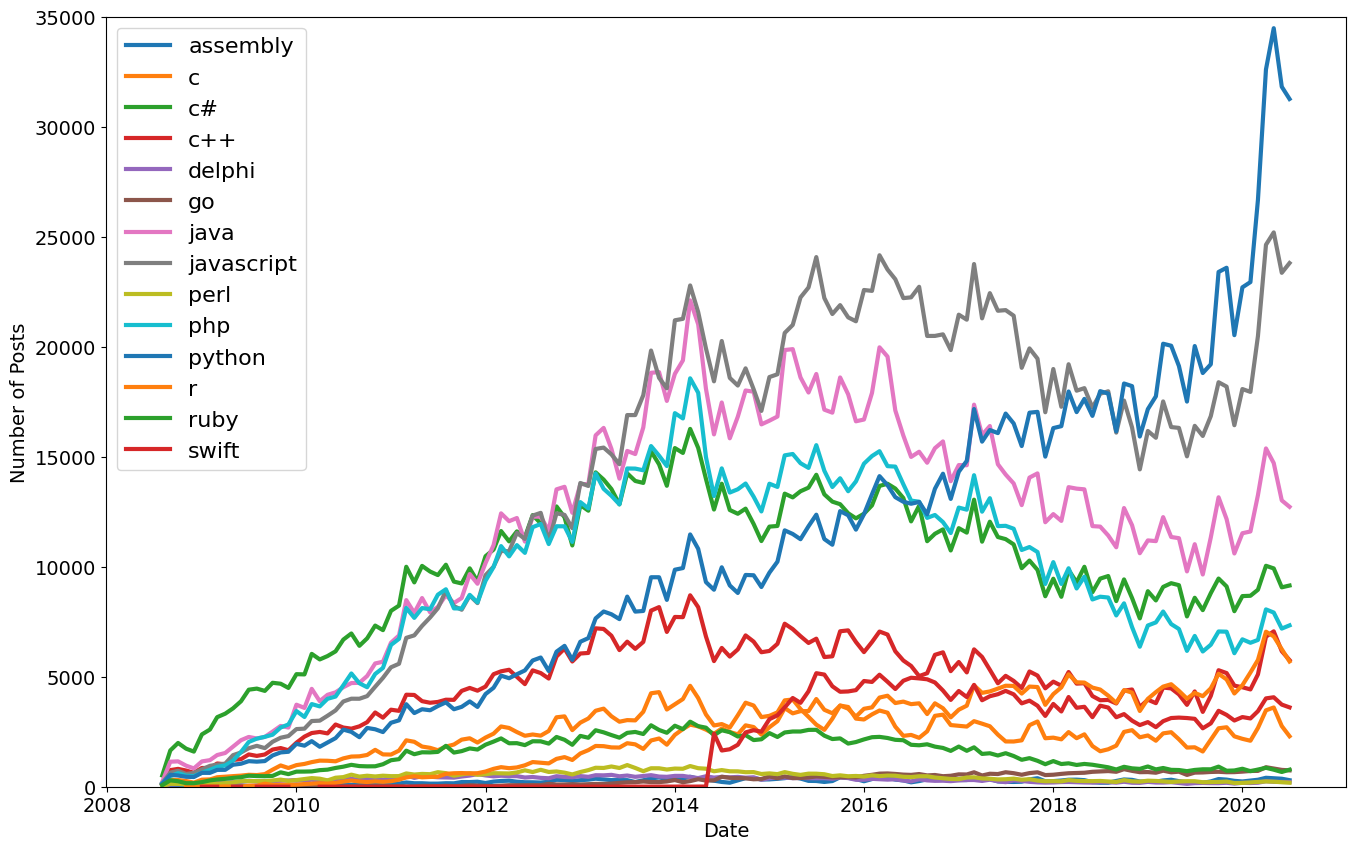

In [53]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], 
             linewidth=3, label=df_pivot[column].name)
 
plt.legend(fontsize=16) 

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

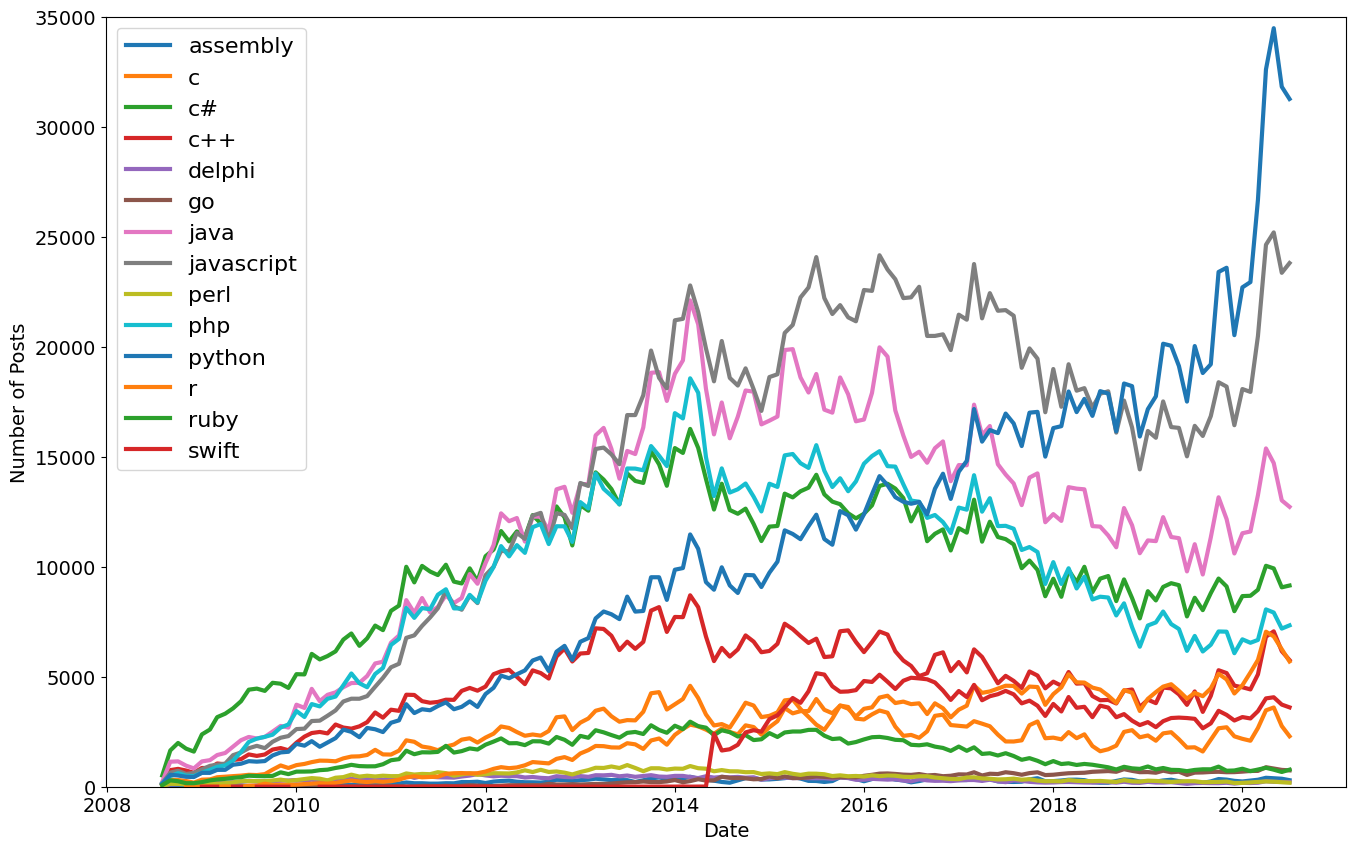

: 

In [ ]:
roll_df = df_pivot.rolling(window=6).mean()
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], 
             linewidth=3, label=df_pivot[column].name)
 
plt.legend(fontsize=16) 